# Exercise 10

# Task 1

## Task 1.1

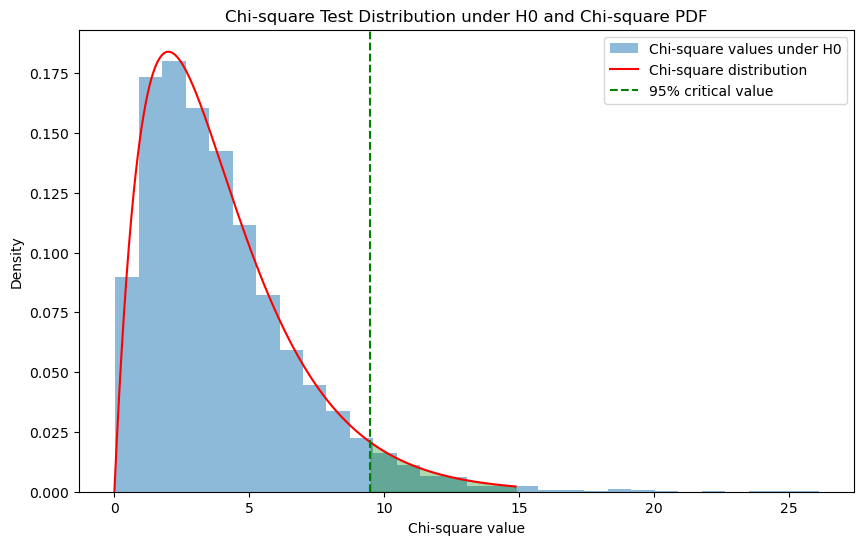

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

flavors = ['Chocolate', 'Vanilla', 'Strawberry', 'Stracciatella', 'Lemon']
probabilities_H0 = [0.4, 0.2, 0.2, 0.1, 0.1]
n = 200
num_samples = 10000

samples_H0 = np.random.multinomial(n, probabilities_H0, size=num_samples)

expected_H0 = np.array(probabilities_H0) * n

chi2_values_H0 = ((samples_H0 - expected_H0)**2 / expected_H0).sum(axis=1)

df = len(flavors) - 1
x = np.linspace(0, chi2.ppf(0.995, df), 1000)
chi2_pdf = chi2.pdf(x, df)

plt.figure(figsize=(10, 6))
plt.hist(chi2_values_H0, bins=30, density=True, alpha=0.5, label='Chi-square values under H0')
plt.plot(x, chi2_pdf, label='Chi-square distribution', color='red')
plt.axvline(chi2.ppf(0.95, df), color='green', linestyle='dashed', label='95% critical value')
extreme_values = x[x >= chi2.ppf(0.95, df)]
plt.fill_between(extreme_values, 0, chi2.pdf(extreme_values, df), color='green', alpha=0.3)
plt.title("Chi-square Test Distribution under H0 and Chi-square PDF")
plt.xlabel("Chi-square value")
plt.ylabel("Density")
plt.legend()
plt.show()

## Task 1.2

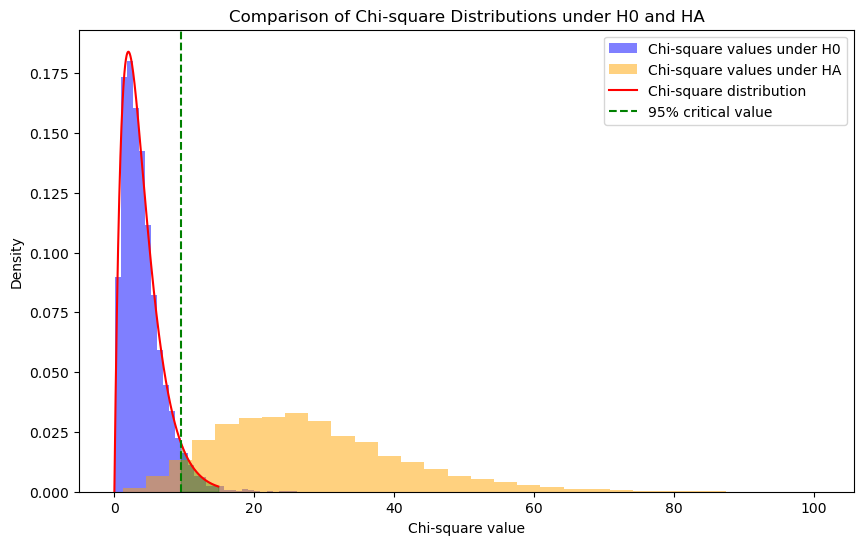

In [7]:
samples_HA = np.random.multinomial(n, probabilities_HA, size=num_samples)

chi2_values_HA = ((samples_HA - expected_H0)**2 / expected_H0).sum(axis=1)

critical_value = chi2.ppf(0.95, df)
type_I_error = np.mean(chi2_values_H0 >= critical_value)
type_II_error = np.mean(chi2_values_HA < critical_value)

plt.figure(figsize=(10, 6))
plt.hist(chi2_values_H0, bins=30, density=True, alpha=0.5, label='Chi-square values under H0', color='blue')
plt.hist(chi2_values_HA, bins=30, density=True, alpha=0.5, label='Chi-square values under HA', color='orange')
plt.plot(x, chi2_pdf, label='Chi-square distribution', color='red')
plt.axvline(critical_value, color='green', linestyle='dashed', label='95% critical value')
plt.fill_between(extreme_values, 0, chi2.pdf(extreme_values, df), color='green', alpha=0.3)
plt.title("Comparison of Chi-square Distributions under H0 and HA")
plt.xlabel("Chi-square value")
plt.ylabel("Density")
plt.legend()
plt.show()

## Task 1.3

In [32]:
sales_actual = np.array([64, 24, 43, 29, 40])

expected_sales = probabilities_H0 * n

chi_square_stat = ((sales_actual - expected_sales)**2 / expected_sales).sum()

df = len(probabilities_H0) - 1

p_value = 1 - chi2.cdf(chi_square_stat, df)

# Find the critical t-value
alpha = 0.05
critical_value = chi2.ppf(1 - alpha, df)
critical_t = chi2.ppf(0.95,df)

if np.abs(critical_t) > critical_value:
    print('The null hypothesis will be rejected')
else:
    print('The null can not be rejected')

chi_square_stat, p_value, critical_value

The null can not be rejected


(33.875, 7.90494999125535e-07, 9.487729036781154)

# Task 2

In [19]:
n = 30
offset = [0, 0.5, -0.8, 0., 0.]

x = [np.random.randn(n) + o for o in offset]

means = [np.mean(g) for g in x]
variances = [np.var(g, ddof=1) for g in x]

F_statistic, p_value = stats.f_oneway(*x)
print("F-statistic:", F_statistic, "P-value:", p_value)

# MSG and MSE
overall_mean = np.mean([item for sublist in x for item in sublist])
SSG = sum([len(g) * (np.mean(g) - overall_mean)**2 for g in x])
MSG = SSG / (len(x) - 1)
SSE = sum([(len(g) - 1) * np.var(g, ddof=1) for g in x])
MSE = SSE / (n * len(x) - len(x))
F_value_manual = MSG / MSE

print("Manual F-value:", F_value_manual)

F-statistic: 6.665805153145003 P-value: 5.9374733654036534e-05
Manual F-value: 6.6658051531449996


# Task 3

## Task 3.1

In [33]:
from scipy.stats import t

donations = np.array([611, 491, 511, 476, 526, 463])

t_statistic, p_value = stats.ttest_1samp(donations, 500)

df = 5

critical_t_value = t.ppf(1 - alpha / 2, df)

if np.abs(t_statistic) > critical_t_value:
    print('The null hypothesis will be rejected')
else:
    print('The null can not be rejected')
    
t_statistic, p_value

The null can not be rejected


(0.5990083808593188, 0.5752716078813219)

## Task 3.2

In [34]:
donations_group2 = np.array([520, 609, 458, 572, 494, 566])

t_statistic_2sample, p_value_2sample = stats.ttest_ind(donations, donations_group2)
    
t_statistic_2sample, p_value_2sample

(-0.7461570873878105, 0.47274863489606866)

In [ ]:
dwdwd